In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/TrafficSignDataset/archive.zip"  # adjust if name differs
extract_path = "/content/gtsrb"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted dataset to:", extract_path)
print("Folders inside extracted path:", os.listdir(extract_path))


Extracted dataset to: /content/gtsrb
Folders inside extracted path: ['Meta.csv', 'Train', 'Meta', 'train', 'meta', 'Test', 'Train.csv', 'Test.csv', 'test']


In [ ]:
import os

train_path = "/content/gtsrb/Train"
classes = sorted(os.listdir(train_path))
print("Total Classes:", len(classes))
print("Sample Classes:", classes[:10])


Total Classes: 43
Sample Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

data = []
labels = []

for class_id in range(len(classes)):
    path = os.path.join(train_path, str(class_id))
    for img_name in os.listdir(path):
        try:
            img = cv2.imread(os.path.join(path, img_name))
            img = cv2.resize(img, (32, 32))
            data.append(img)
            labels.append(class_id)
        except:
            print("Error loading image:", img_name)

X = np.array(data)
y = np.array(labels)

# Normalize images
X = X / 255.0

# One-hot encode labels
y = to_categorical(y, len(classes))

print("Data shape:", X.shape)
print("Labels shape:", y.shape)


Data shape: (39209, 32, 32, 3)
Labels shape: (39209, 43)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 31367
Validation samples: 7842


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')  # 43 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2017 - loss: 3.0031 - val_accuracy: 0.8039 - val_loss: 0.7223
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7617 - loss: 0.7588 - val_accuracy: 0.9407 - val_loss: 0.2212
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9065 - loss: 0.3106 - val_accuracy: 0.9707 - val_loss: 0.1105
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9447 - loss: 0.1864 - val_accuracy: 0.9782 - val_loss: 0.0773
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9562 - loss: 0.1486 - val_accuracy: 0.9806 - val_loss: 0.0694
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9698 - loss: 0.1034 - val_accuracy: 0.9850 - val_loss: 0.0540
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9760 - loss: 0.0836 - val_accuracy: 0.9875 - val_loss: 0.0440
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9798 - loss: 0.0648 - val_accuracy: 

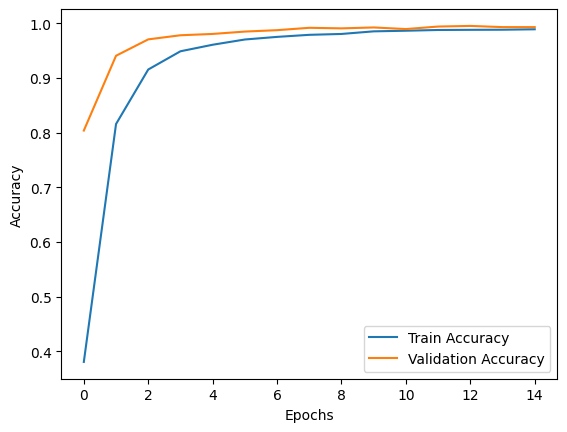

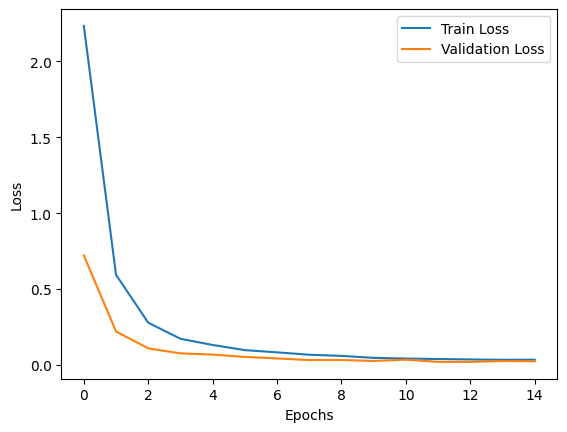

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
model.save("traffic_sign_model.h5")
print("Model saved as traffic_sign_model.h5")


Model saved as traffic_sign_model.h5


In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
from google.colab import files

# Load your trained model
model = load_model("traffic_sign_model.h5")

# Class mapping dictionary (43 classes)
classes_names = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5 metric tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5 metric tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5 metric tons'
}

# Function to predict traffic sign
def predict_traffic_sign(img_path):
    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR → RGB
    img = cv2.resize(img, (32, 32))  # Resize to model input size
    img = np.expand_dims(img, axis=0) / 255.0  # Normalize

    # Prediction
    pred = model.predict(img)
    class_index = np.argmax(pred)
    return class_index, classes_names[class_index]

# Upload and test
uploaded = files.upload()
for filename in uploaded.keys():
    idx, name = predict_traffic_sign(filename)
    print(f"Predicted Class: {idx} → {name}")


Saving 00001.png to 00001 (4).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
Predicted Class: 1 → Speed limit (30km/h)


In [ ]:
# Save as H5
model.save("traffic_sign_model.h5")

# Download to your local machine
from google.colab import files
files.download("traffic_sign_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
scores = model.evaluate(X_test, y_test, verbose=1)
print("Accuracy: %.2f%%" % (scores[1]*100))
